# Istanbul Solid Waste Route Optimization — Exploratory Data Analysis


| # | File | Role in CVRP |
|---|------|--------------|
| 1 | `evsel-atk_kat_atk_aktarma_2025.xlsx` | Demand **q_i** (waste load + trips / municipality) |
| 2 | `kati-atik-aktarma-istasyonlari-konumlari.xlsx` | Transfer station coords (set **S**) |
| 3 | `cop-kamyonu-says.xlsx` | Fleet size **\|K\|** by side / year |
| 4 | `waste_facility.csv` | All facility types → disposal set **F** |
| 5 | `traffic_density_202501.csv` | Hourly speeds → congestion factor **α_r** |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import folium
import re
import json
from pathlib import Path
from math import radians, sin, cos, sqrt, atan2

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110

DATA = Path('../datas')
OUT  = Path('../outputs')
OUT.mkdir(exist_ok=True)

print('pandas', pd.__version__)
print('Data files:', [f.name for f in DATA.iterdir()])

pandas 3.0.2
Data files: ['cop-kamyonu-says.xlsx', 'evsel-atk_kat_atk_aktarma_2025.xlsx', 'kati-atik-aktarma-istasyonlari-konumlari.xlsx', 'traffic_density_202501.csv', 'waste_facility.csv']


---
## 1. Dataset 3 — Truck Fleet (`cop-kamyonu-says.xlsx`)

In [2]:
fleet_raw = pd.read_excel(DATA / 'cop-kamyonu-says.xlsx', engine='openpyxl')
fleet_raw.columns = ['year', 'asia', 'europe']
fleet_raw['total'] = fleet_raw['asia'] + fleet_raw['europe']
print(fleet_raw.to_string(index=False))

 year  asia  europe  total
 2021    31      44     75
 2022    31      44     75
 2023    31      44     75
 2024    32      42     74
 2025    43      39     82


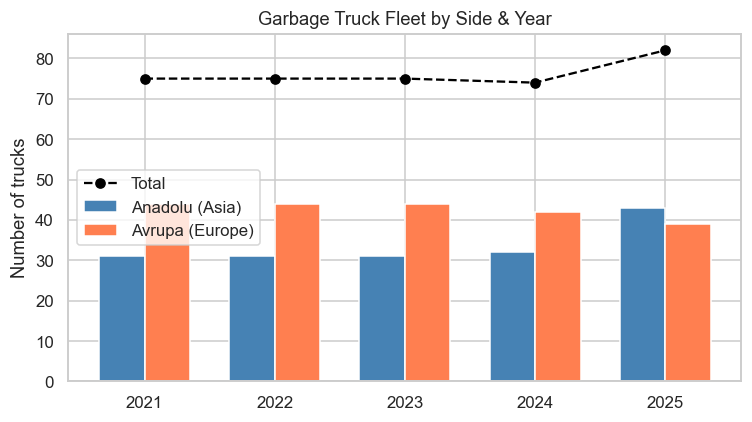


2025 fleet  →  Asia: 43  |  Europe: 39  |  Total: 82


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
width = 0.35
x = np.arange(len(fleet_raw))
ax.bar(x - width/2, fleet_raw['asia'],   width, label='Anadolu (Asia)',   color='steelblue')
ax.bar(x + width/2, fleet_raw['europe'], width, label='Avrupa (Europe)', color='coral')
ax.plot(x, fleet_raw['total'], 'k--o', label='Total', linewidth=1.5)
ax.set_xticks(x); ax.set_xticklabels(fleet_raw['year'])
ax.set_ylabel('Number of trucks'); ax.set_title('Garbage Truck Fleet by Side & Year')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'fleet_by_year.png', dpi=130)
plt.show()

# 2025 reference values for the CVRP model
fleet_2025 = fleet_raw[fleet_raw['year'] == 2025].iloc[0]
K_asia, K_europe, K_total = int(fleet_2025['asia']), int(fleet_2025['europe']), int(fleet_2025['total'])
print(f'\n2025 fleet  →  Asia: {K_asia}  |  Europe: {K_europe}  |  Total: {K_total}')

---
## 2. Dataset 2 — Transfer Station Locations (`kati-atik-aktarma-istasyonlari-konumlari.xlsx`)

In [4]:
stations_raw = pd.read_excel(DATA / 'kati-atik-aktarma-istasyonlari-konumlari.xlsx', engine='openpyxl')
stations_raw.columns = ['name', 'address', 'lat', 'lon', 'area_m2']
print(f'Shape: {stations_raw.shape}')
display(stations_raw)

Shape: (9, 5)


,name,address,lat,lon,area_m2
0,Baruthane Katı Atık Aktarma İstasyonu,Paşa Mah. Piyalepaşa Bulvarı No:74 Şişli,41.048990,28.968704,6000
1,Yenibosna Katı Atık Aktarma İstasyonu,Yenibosna Sanayi Cad. / Bahçelievler,40.997941,28.825066,33000
2,Başakşehir Katı Atık Aktarma İstasyonu,Kayabaşı Mah. İstiklal Cad. / Başakşehir,41.146396,28.778397,26288
3,Silivri Katı Atık Aktarma İstasyonu,Yenimahalle 1 Kasım Cad. Hasan Çeşme Mevkii / ...,41.091038,28.290184,11950
4,Hasdal Katı Atık Aktarma İstasyonu,Kemerburgaz Yolu Eski Hasdal Çöplüğü Hasdal Ke...,41.137224,28.930791,27000
5,Küçük Bakkalköy Katı Atık Aktarma İstasyonu,Atatürk Mah. Erzincan Cad. K.Bakkalköy / Kadıköy,40.985205,29.129967,20000
6,Hekimbaşı Katı Atık Aktama İstasyonu,Hekimbaşı Mah.Küçüksu Cad. No: Bila Ümraniye/İ...,41.058319,29.113407,30000
7,Aydınlı Katı Atık Aktarma İstasyonu,Aydınlı Köyü Patlayıcılar Yolu / Tuzla,40.860882,29.347151,48000
8,Şile Katı Atık Aktarma İstasyonu,Şile Araç Muayene İstasyonu Yanı – Şile,41.153138,29.639464,11000


In [5]:
# Missing value check
print('Missing values:')
print(stations_raw.isnull().sum())
print('\nData types:')
print(stations_raw.dtypes)

Missing values:
name       0
address    0
lat        0
lon        0
area_m2    0
dtype: int64

Data types:
name           str
address        str
lat        float64
lon        float64
area_m2      int64
dtype: object


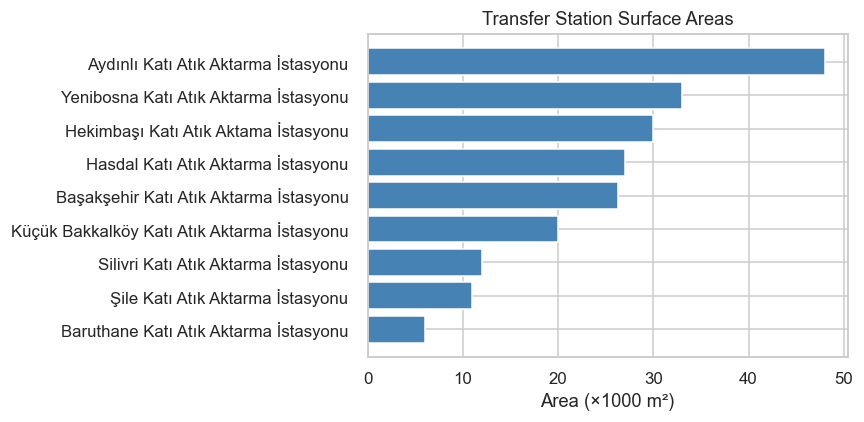

In [6]:
# Station area distribution
fig, ax = plt.subplots(figsize=(8, 4))
stations_raw_sorted = stations_raw.sort_values('area_m2')
ax.barh(stations_raw_sorted['name'], stations_raw_sorted['area_m2'] / 1000, color='steelblue')
ax.set_xlabel('Area (×1000 m²)')
ax.set_title('Transfer Station Surface Areas')
plt.tight_layout()
plt.savefig(OUT / 'station_areas.png', dpi=130)
plt.show()

In [7]:
# Interactive map of transfer stations
m_stations = folium.Map(location=[41.01, 28.95], zoom_start=10, tiles='CartoDB positron')
for _, row in stations_raw.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=8,
        color='steelblue', fill=True, fill_opacity=0.85,
        popup=folium.Popup(f"<b>{row['name']}</b><br>Area: {row['area_m2']:,} m²", max_width=250)
    ).add_to(m_stations)
m_stations.save(OUT / 'stations_map.html')
m_stations

---
## 3. Dataset 1 — Waste Volumes & Trips (`evsel-atk_kat_atk_aktarma_2025.xlsx`)

In [8]:
volumes_raw = pd.read_excel(DATA / 'evsel-atk_kat_atk_aktarma_2025.xlsx', engine='openpyxl')
volumes_raw.columns = ['municipality', 'trips', 'waste_kg']
volumes_raw['waste_tonnes'] = volumes_raw['waste_kg'] / 1000
print(f'Shape: {volumes_raw.shape}')
display(volumes_raw.head(10))

Shape: (48, 4)


,municipality,trips,waste_kg,waste_tonnes
0,ADALAR BELEDİYESİ,85,473800,473.80
1,ARNAVUTKÖY BELEDİYESİ,1132,9171540,9171.54
2,ATAŞEHİR BELEDİYESİ,2480,13545020,13545.02
3,AVCILAR BELEDİYESİ,1166,8339970,8339.97
4,BAĞCILAR BELEDİYESİ,2578,16996380,16996.38
5,BAHÇELİEVLER BELEDİYESİ,3701,15671090,15671.09
6,BAKIRKÖY BELEDİYESİ,1332,8132370,8132.37
7,BAŞAKŞEHİR BELEDİYESİ,1297,9159480,9159.48
8,BAYRAMPAŞA BELEDİYESİ,452,2702220,2702.22
9,BEŞİKTAŞ BELEDİYESİ,1858,8081180,8081.18


In [9]:
# Missing / anomalies check
print('Missing values:')
print(volumes_raw.isnull().sum())
print(f'\nTotal waste  : {volumes_raw["waste_tonnes"].sum():,.1f} tonnes (Jan 2025)')
print(f'Total trips  : {volumes_raw["trips"].sum():,}')
print(f'Municipalities: {volumes_raw["municipality"].nunique()}')

Missing values:
municipality    0
trips           0
waste_kg        0
waste_tonnes    0
dtype: int64

Total waste  : 375,031.5 tonnes (Jan 2025)
Total trips  : 64,267
Municipalities: 48


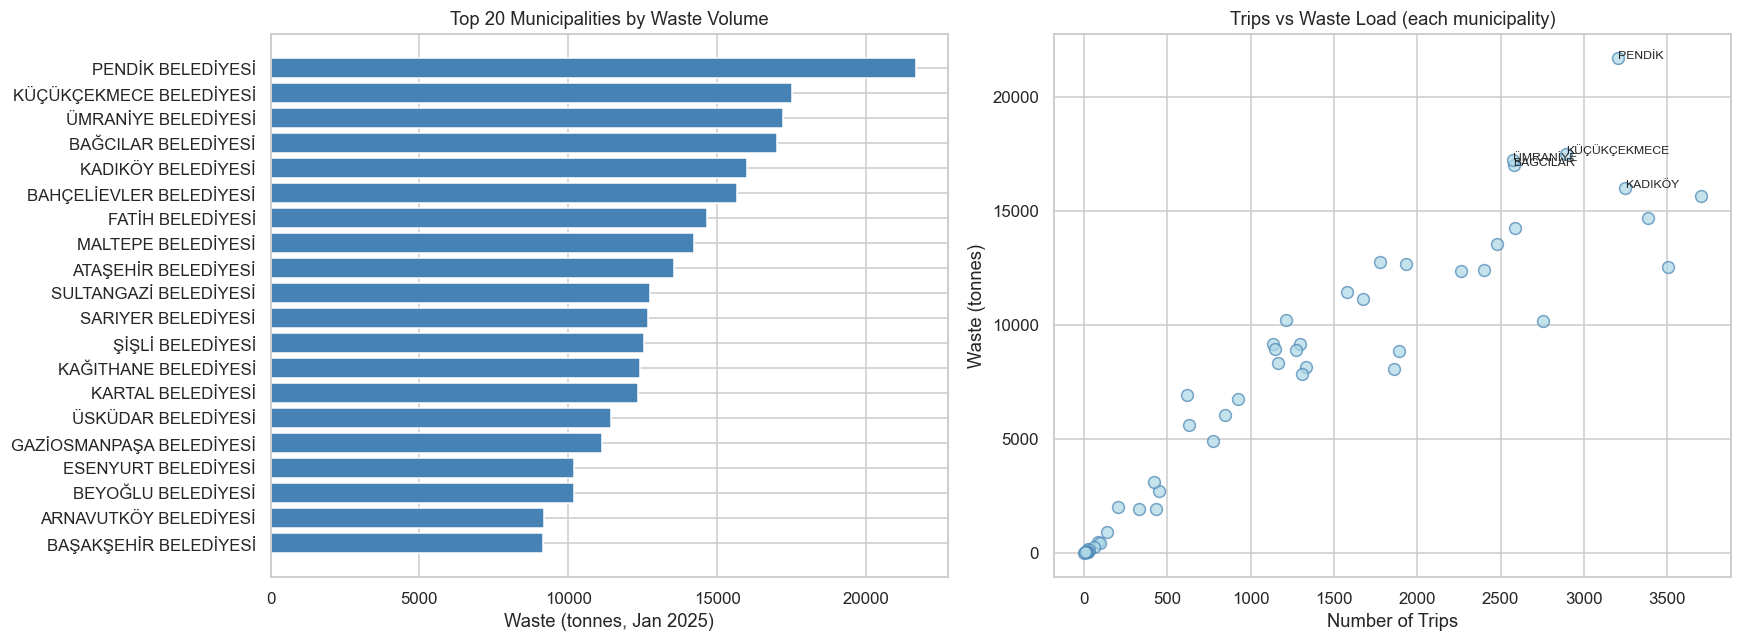

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Waste by municipality
top = volumes_raw.sort_values('waste_tonnes', ascending=False).head(20)
axes[0].barh(top['municipality'], top['waste_tonnes'], color='steelblue')
axes[0].set_xlabel('Waste (tonnes, Jan 2025)')
axes[0].set_title('Top 20 Municipalities by Waste Volume')
axes[0].invert_yaxis()

# Trips vs waste scatter
axes[1].scatter(volumes_raw['trips'], volumes_raw['waste_tonnes'], 
                alpha=0.7, edgecolors='steelblue', facecolors='lightblue', s=60)
for _, row in volumes_raw.sort_values('waste_tonnes', ascending=False).head(5).iterrows():
    axes[1].annotate(row['municipality'].split()[0], 
                     (row['trips'], row['waste_tonnes']), fontsize=8)
axes[1].set_xlabel('Number of Trips')
axes[1].set_ylabel('Waste (tonnes)')
axes[1].set_title('Trips vs Waste Load (each municipality)')

plt.tight_layout()
plt.savefig(OUT / 'waste_volumes.png', dpi=130)
plt.show()

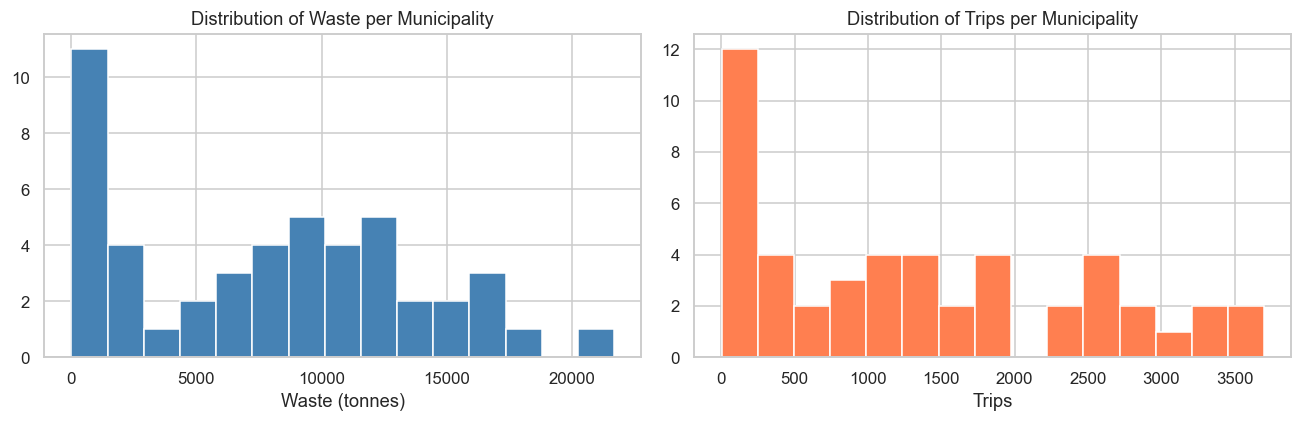

In [11]:
# Distribution of waste and trips
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(volumes_raw['waste_tonnes'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Waste (tonnes)'); axes[0].set_title('Distribution of Waste per Municipality')
axes[1].hist(volumes_raw['trips'], bins=15, color='coral', edgecolor='white')
axes[1].set_xlabel('Trips'); axes[1].set_title('Distribution of Trips per Municipality')
plt.tight_layout()
plt.savefig(OUT / 'waste_distributions.png', dpi=130)
plt.show()

> **Note on merge:** `volumes_raw` has 48 municipality rows; `stations_raw` has 9 physical stations. These do **not** share names — the volumes represent source municipalities sending waste *to* the physical transfer stations. The merge is done later by assigning each municipality to its nearest station using Haversine distance (requires municipality centroids, approximated from IBB district data or looked up externally).

---
## 4. Dataset 4 — Waste Facilities (`waste_facility.csv`)

In [12]:
facilities_raw = pd.read_csv(DATA / 'waste_facility.csv')
print(f'Shape: {facilities_raw.shape}')
print('Columns:', list(facilities_raw.columns))
display(facilities_raw[['objectid','facility_name','status','located_region_name','shape']].head(10))

Shape: (27, 10)
Columns: ['objectid', 'facility_name', 'status', 'address', 'neighborhood_uavt_code', 'neighborhood_name', 'county_uavt_code', 'county', 'located_region_name', 'shape']


,objectid,facility_name,status,located_region_name,shape
0,16,Elektronik Atık İşleme ve Geri Kazanım Tesisi,Mevcut,Avrupa,POINT (28.8254799997465 40.9970129986921)
1,17,Maltepe Hizmet Birimi,Mevcut,Anadolu,POINT (29.155083599478 40.9344252894451)
2,11,Odayeri Düzenli Depolama Alanı Tıbbi Atık Yakm...,Mevcut,Avrupa,POINT (28.8545650003672 41.2161579991942)
3,5,Silivri Katı Atık Aktarma İstasyonu,Mevcut,Avrupa,POINT (28.2901838395005 41.0910384187238)
4,21,Aydınlı Katı Atık Aktarma İstasyonu,Mevcut,Anadolu,POINT (29.3471512196003 40.8608823494234)
5,23,Kömürcüoda Düzenli Depolama Alanı,Mevcut,Anadolu,POINT (29.3692714005402 41.1508654587288)
6,18,Ümraniye Hizmet Birimi,Mevcut,Anadolu,POINT (29.1057799005654 41.0573148489299)
7,9,Gaziosmanpaşa Hizmet Birimi,Mevcut,Avrupa,POINT (28.8873780001592 41.0918899991622)
8,13,Odayeri Düzenli Depolama Alanı,Mevcut,Avrupa,POINT (28.8577619995369 41.2127199994295)
9,26,Kömürcüoda Endüstriyel Atık Tesisi,Mevcut,Anadolu,POINT (29.3769867698783 41.1461847590375)


In [13]:
# Parse WKT POINT (lon lat) into numeric columns
def parse_wkt(wkt):
    m = re.search(r'POINT\s*\(([\d.]+)\s+([\d.]+)\)', str(wkt))
    return (float(m.group(2)), float(m.group(1))) if m else (np.nan, np.nan)  # returns (lat, lon)

facilities_raw[['lat', 'lon']] = facilities_raw['shape'].apply(parse_wkt).apply(pd.Series)

# Status summary
print('Status breakdown:')
print(facilities_raw['status'].value_counts())
print('\nRegion breakdown:')
print(facilities_raw['located_region_name'].value_counts())
print('\nMissing coords:', facilities_raw[['lat','lon']].isnull().any(axis=1).sum())

Status breakdown:
status
Mevcut    26
Proje      1
Name: count, dtype: int64

Region breakdown:
located_region_name
Avrupa     16
Anadolu    11
Name: count, dtype: int64

Missing coords: 0


In [14]:
# Infer facility type from name
def classify_facility(name):
    n = str(name).lower()
    if 'aktarma' in n:       return 'Transfer Station (S)'
    if 'depolama' in n:      return 'Disposal Site (F)'
    if 'kompost' in n:       return 'Composting (F)'
    if 'enerji' in n or 'lfg' in n: return 'Energy/LFG (F)'
    if 'hizmet' in n:        return 'Service Unit'
    if 'elektronik' in n:    return 'E-Waste'
    if 'endüstriyel' in n or 'endustriyel' in n: return 'Industrial'
    return 'Other'

facilities_raw['node_type'] = facilities_raw['facility_name'].apply(classify_facility)
print(facilities_raw['node_type'].value_counts())
display(facilities_raw[['facility_name','status','located_region_name','node_type','lat','lon']])

node_type
Service Unit            8
Transfer Station (S)    8
Disposal Site (F)       3
Energy/LFG (F)          3
Composting (F)          2
E-Waste                 1
Industrial              1
Other                   1
Name: count, dtype: int64


,facility_name,status,located_region_name,node_type,lat,lon
0,Elektronik Atık İşleme ve Geri Kazanım Tesisi,Mevcut,Avrupa,E-Waste,40.997013,28.825480
1,Maltepe Hizmet Birimi,Mevcut,Anadolu,Service Unit,40.934425,29.155084
2,Odayeri Düzenli Depolama Alanı Tıbbi Atık Yakm...,Mevcut,Avrupa,Disposal Site (F),41.216158,28.854565
3,Silivri Katı Atık Aktarma İstasyonu,Mevcut,Avrupa,Transfer Station (S),41.091038,28.290184
4,Aydınlı Katı Atık Aktarma İstasyonu,Mevcut,Anadolu,Transfer Station (S),40.860882,29.347151
5,Kömürcüoda Düzenli Depolama Alanı,Mevcut,Anadolu,Disposal Site (F),41.150865,29.369271
6,Ümraniye Hizmet Birimi,Mevcut,Anadolu,Service Unit,41.057315,29.105780
7,Gaziosmanpaşa Hizmet Birimi,Mevcut,Avrupa,Service Unit,41.091890,28.887378
8,Odayeri Düzenli Depolama Alanı,Mevcut,Avrupa,Disposal Site (F),41.212720,28.857762
9,Kömürcüoda Endüstriyel Atık Tesisi,Mevcut,Anadolu,Industrial,41.146185,29.376987


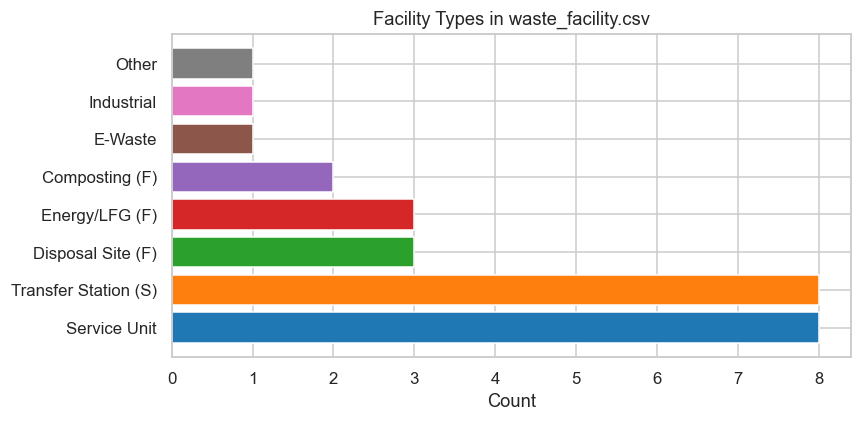

In [15]:
# Node type bar chart
fig, ax = plt.subplots(figsize=(8, 4))
type_counts = facilities_raw['node_type'].value_counts()
colors = sns.color_palette('tab10', len(type_counts))
ax.barh(type_counts.index, type_counts.values, color=colors)
ax.set_xlabel('Count')
ax.set_title('Facility Types in waste_facility.csv')
plt.tight_layout()
plt.savefig(OUT / 'facility_types.png', dpi=130)
plt.show()

In [16]:
# Interactive map — all facilities colored by type
type_colors = {
    'Transfer Station (S)': 'blue',
    'Disposal Site (F)':    'red',
    'Composting (F)':       'green',
    'Energy/LFG (F)':       'orange',
    'Service Unit':         'gray',
    'E-Waste':              'purple',
    'Industrial':           'darkred',
    'Other':                'black',
}

m_all = folium.Map(location=[41.01, 28.95], zoom_start=10, tiles='CartoDB positron')
for _, row in facilities_raw.dropna(subset=['lat','lon']).iterrows():
    color = type_colors.get(row['node_type'], 'black')
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=8, color=color, fill=True, fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>{row['facility_name']}</b><br>Type: {row['node_type']}<br>Region: {row['located_region_name']}<br>Status: {row['status']}",
            max_width=280)
    ).add_to(m_all)

# Also plot transfer stations from xlsx (larger markers)
for _, row in stations_raw.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(f"<b>[xlsx] {row['name']}</b>", max_width=250),
        icon=folium.Icon(color='blue', icon='home', prefix='fa')
    ).add_to(m_all)

m_all.save(OUT / 'all_facilities_map.html')
m_all

---
## 5. Dataset 5 — Hourly Traffic Density (`traffic_density_202501.csv`)

File is ~141 MB / 1.76M+ rows. Read in **chunks** to avoid memory blowups.

In [17]:
CHUNK = 200_000
traffic_file = DATA / 'traffic_density_202501.csv'

# Pass 1: collect hour-of-day stats and a spatial sample
hour_buckets = {}   # hour -> list of AVERAGE_SPEED values (sampled)
spatial_sample = []
total_rows = 0
null_counts = {c: 0 for c in ['DATE_TIME','LATITUDE','LONGITUDE','GEOHASH',
                                'MINIMUM_SPEED','MAXIMUM_SPEED','AVERAGE_SPEED','NUMBER_OF_VEHICLES']}
speed_spread_extreme = 0   # rows where (MAX - MIN) > 100
rng = np.random.default_rng(42)

for chunk in pd.read_csv(traffic_file, chunksize=CHUNK, parse_dates=['DATE_TIME']):
    total_rows += len(chunk)
    for c in null_counts:
        null_counts[c] += chunk[c].isnull().sum()
    chunk['hour'] = chunk['DATE_TIME'].dt.hour
    chunk['dow']  = chunk['DATE_TIME'].dt.dayofweek  # 0=Mon
    speed_spread_extreme += ((chunk['MAXIMUM_SPEED'] - chunk['MINIMUM_SPEED']) > 100).sum()

    for h, grp in chunk.groupby('hour'):
        speeds = grp['AVERAGE_SPEED'].dropna().values
        if h not in hour_buckets:
            hour_buckets[h] = []
        # keep at most 5000 random samples per hour across all chunks
        hour_buckets[h].extend(rng.choice(speeds, min(500, len(speeds)), replace=False).tolist())

    # spatial sample: take 0.5% of each chunk
    idx = rng.choice(len(chunk), max(1, len(chunk)//200), replace=False)
    spatial_sample.append(chunk.iloc[idx][['LATITUDE','LONGITUDE','AVERAGE_SPEED','hour','dow']].copy())

spatial_df = pd.concat(spatial_sample, ignore_index=True)
print(f'Total rows: {total_rows:,}')
print(f'Rows with extreme speed spread (max-min > 100): {speed_spread_extreme:,} ({speed_spread_extreme/total_rows*100:.2f}%)')
print('\nNull counts:')
for k,v in null_counts.items():
    print(f'  {k}: {v}')

Total rows: 1,763,963
Rows with extreme speed spread (max-min > 100): 395,338 (22.41%)

Null counts:
  DATE_TIME: 0
  LATITUDE: 0
  LONGITUDE: 0
  GEOHASH: 0
  MINIMUM_SPEED: 0
  MAXIMUM_SPEED: 0
  AVERAGE_SPEED: 0
  NUMBER_OF_VEHICLES: 0


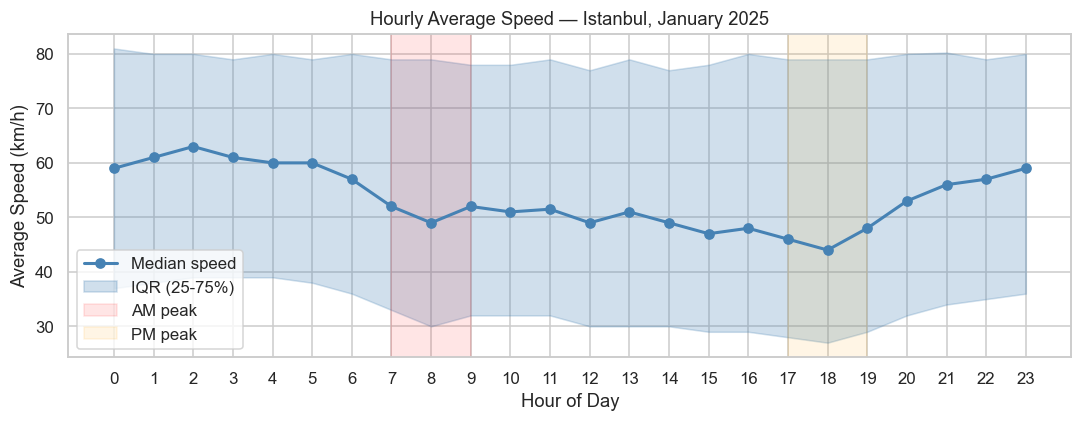

In [18]:
# Hour-of-day speed statistics
hours = sorted(hour_buckets.keys())
medians = [np.median(hour_buckets[h]) for h in hours]
q25    = [np.percentile(hour_buckets[h], 25) for h in hours]
q75    = [np.percentile(hour_buckets[h], 75) for h in hours]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hours, medians, 'o-', color='steelblue', linewidth=2, label='Median speed')
ax.fill_between(hours, q25, q75, alpha=0.25, color='steelblue', label='IQR (25-75%)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Speed (km/h)')
ax.set_title('Hourly Average Speed — Istanbul, January 2025')
ax.set_xticks(hours)
ax.axvspan(7, 9, alpha=0.1, color='red', label='AM peak')
ax.axvspan(17, 19, alpha=0.1, color='orange', label='PM peak')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'hourly_speed_curve.png', dpi=130)
plt.show()

Free-flow baseline (90th pct of 01-05h): 88.0 km/h


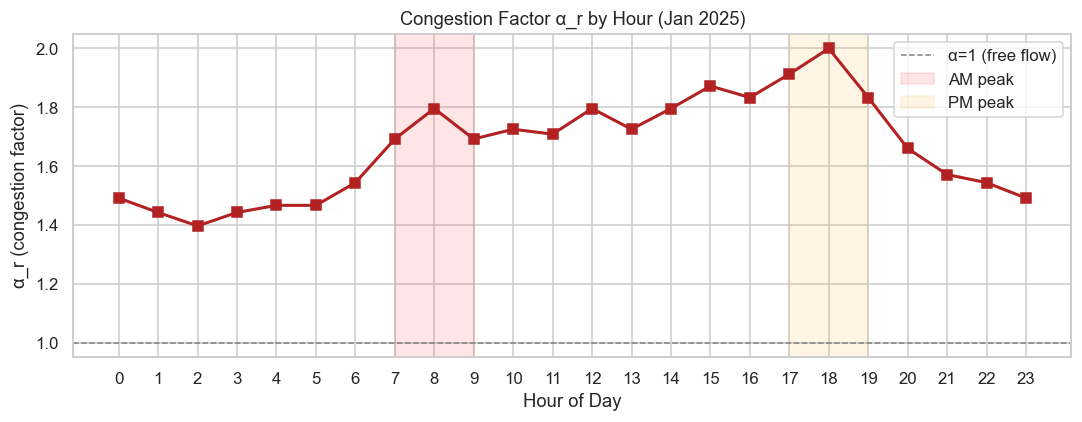


alpha_r values:
  Hour 00: 1.4915
  Hour 01: 1.4426
  Hour 02: 1.3968
  Hour 03: 1.4426
  Hour 04: 1.4667
  Hour 05: 1.4667
  Hour 06: 1.5439
  Hour 07: 1.6923
  Hour 08: 1.7959
  Hour 09: 1.6923
  Hour 10: 1.7255
  Hour 11: 1.7087
  Hour 12: 1.7959
  Hour 13: 1.7255
  Hour 14: 1.7959
  Hour 15: 1.8723
  Hour 16: 1.8333
  Hour 17: 1.913
  Hour 18: 2.0
  Hour 19: 1.8333
  Hour 20: 1.6604
  Hour 21: 1.5714
  Hour 22: 1.5439
  Hour 23: 1.4915


In [19]:
# Congestion factor alpha_r = v_free / v_r  (free-flow = 90th percentile of nightly speeds 01-05)
night_hours = [1, 2, 3, 4, 5]
night_speeds = [s for h in night_hours for s in hour_buckets.get(h, [])]
v_free = float(np.percentile(night_speeds, 90)) if night_speeds else 80.0
print(f'Free-flow baseline (90th pct of 01-05h): {v_free:.1f} km/h')

alpha_r = {h: round(v_free / max(np.median(hour_buckets[h]), 1), 4) for h in hours}

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hours, [alpha_r[h] for h in hours], 's-', color='firebrick', linewidth=2)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='α=1 (free flow)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('α_r (congestion factor)')
ax.set_title('Congestion Factor α_r by Hour (Jan 2025)')
ax.set_xticks(hours)
ax.axvspan(7, 9, alpha=0.1, color='red', label='AM peak')
ax.axvspan(17, 19, alpha=0.1, color='orange', label='PM peak')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'alpha_r_congestion.png', dpi=130)
plt.show()

print('\nalpha_r values:')
for h in hours:
    print(f'  Hour {h:02d}: {alpha_r[h]}')

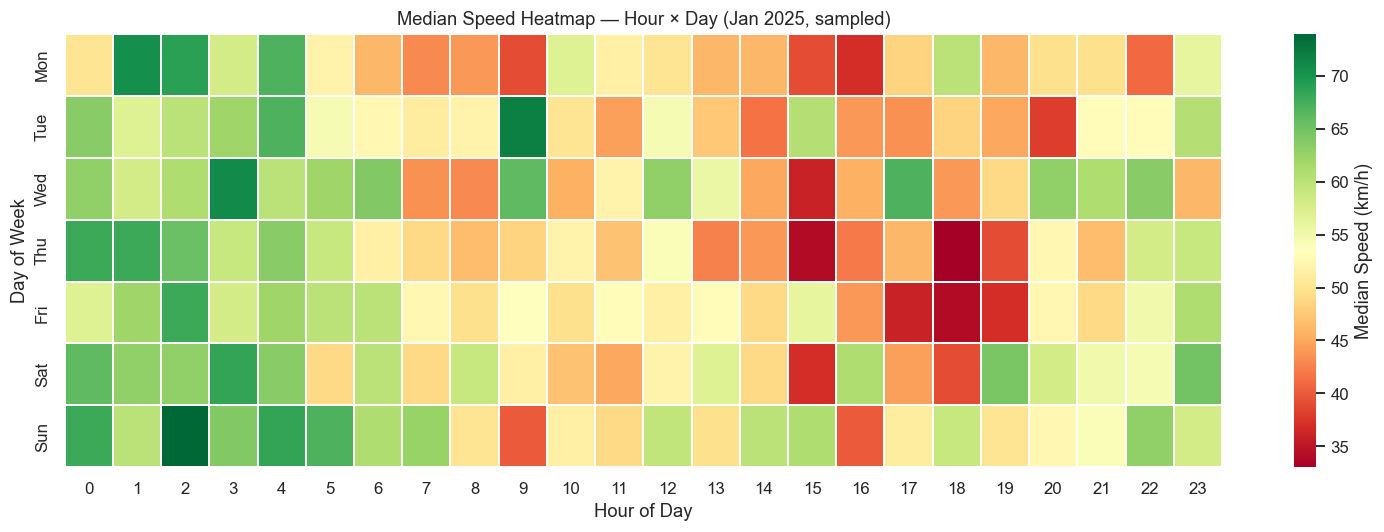

In [20]:
# Heatmap: hour × day-of-week median speed
# Recompute from spatial sample (has hour and dow)
heatmap_data = spatial_df.groupby(['dow','hour'])['AVERAGE_SPEED'].median().unstack(fill_value=np.nan)
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, ax=ax, cmap='RdYlGn', linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Median Speed (km/h)'},
            yticklabels=[day_labels[i] for i in heatmap_data.index])
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Day of Week')
ax.set_title('Median Speed Heatmap — Hour × Day (Jan 2025, sampled)')
plt.tight_layout()
plt.savefig(OUT / 'speed_heatmap_hour_dow.png', dpi=130)
plt.show()

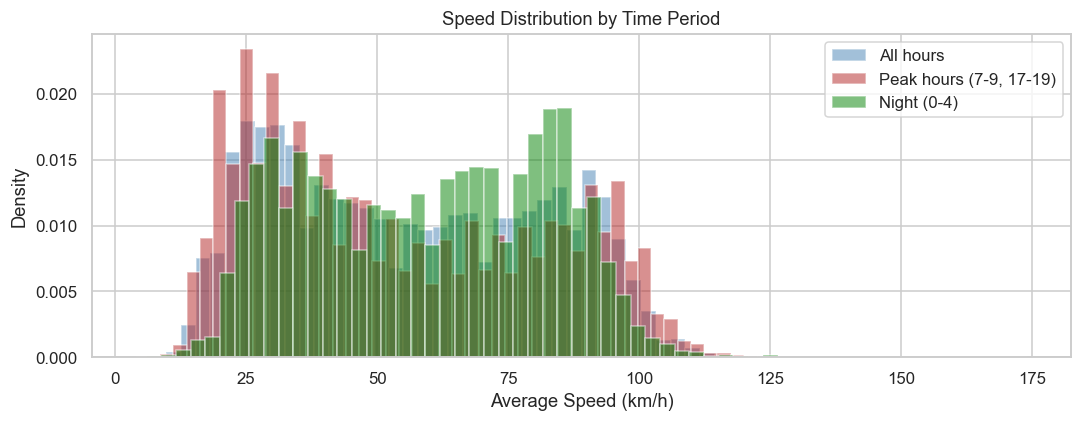

In [21]:
# Speed distribution histograms
all_speeds = [s for h in hours for s in hour_buckets[h]]
peak_speeds  = [s for h in [7,8,9,17,18,19] for s in hour_buckets.get(h, [])]
night_speeds2 = [s for h in [0,1,2,3,4] for s in hour_buckets.get(h, [])]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_speeds,   bins=60, alpha=0.5, label='All hours',  color='steelblue',  density=True)
ax.hist(peak_speeds,  bins=60, alpha=0.5, label='Peak hours (7-9, 17-19)', color='firebrick', density=True)
ax.hist(night_speeds2,bins=60, alpha=0.5, label='Night (0-4)', color='green', density=True)
ax.set_xlabel('Average Speed (km/h)')
ax.set_ylabel('Density')
ax.set_title('Speed Distribution by Time Period')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'speed_distributions.png', dpi=130)
plt.show()

In [22]:
# Spatial coverage map (sampled traffic cells for one peak hour)
peak_sample = spatial_df[spatial_df['hour'] == 8].sample(min(3000, len(spatial_df[spatial_df['hour'] == 8])), random_state=42)

m_traffic = folium.Map(location=[41.01, 28.95], zoom_start=10, tiles='CartoDB positron')
# Color by speed: slow=red, fast=green
vmin, vmax = peak_sample['AVERAGE_SPEED'].min(), peak_sample['AVERAGE_SPEED'].max()
cmap = plt.cm.RdYlGn

for _, row in peak_sample.iterrows():
    norm_speed = (row['AVERAGE_SPEED'] - vmin) / max(vmax - vmin, 1)
    r, g, b, _ = cmap(norm_speed)
    hex_color = '#{:02x}{:02x}{:02x}'.format(int(r*255), int(g*255), int(b*255))
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=3, color=hex_color, fill=True, fill_opacity=0.6, stroke=False
    ).add_to(m_traffic)

# Overlay station markers
for _, row in stations_raw.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        icon=folium.Icon(color='blue', icon='home', prefix='fa'),
        popup=row['name']
    ).add_to(m_traffic)

m_traffic.save(OUT / 'traffic_coverage_08h.html')
m_traffic

---
## 6. Data Cleaning & Merge — Station Locations + Waste Volumes

**Problem:** `kati-atik-aktarma-istasyonlari-konumlari.xlsx` has **9 physical stations**; `evsel-atk_kat_atk_aktarma_2025.xlsx` has **48 municipality rows** (each municipality sends waste *to* a station).  
**Strategy:** Assign each municipality to its nearest physical station using Haversine distance and approximate municipality centroids (looked up from known Istanbul district centre lat/lons).

In [23]:
# Istanbul district (ilçe) approximate centroids — lat, lon
# Source: well-known geographic centers, used only for nearest-station assignment
DISTRICT_CENTROIDS = {
    'ADALAR':         (40.878, 29.090),  'ARNAVUTKÖY':     (41.195, 28.739),
    'ATAŞEHİR':       (40.984, 29.127),  'AVCILAR':        (40.979, 28.722),
    'BAĞCILAR':       (41.040, 28.856),  'BAHÇELİEVLER':   (41.000, 28.860),
    'BAKIRKÖY':       (40.981, 28.874),  'BAŞAKŞEHİR':     (41.092, 28.804),
    'BAYRAMPAŞA':     (41.042, 28.913),  'BEŞİKTAŞ':       (41.043, 29.007),
    'BEYKOZ':         (41.133, 29.097),  'BEYLİKDÜZÜ':     (40.981, 28.647),
    'BEYOĞLU':        (41.036, 28.978),  'BÜYÜKÇEKMECE':   (41.024, 28.587),
    'ÇATALCA':        (41.143, 28.460),  'ÇEKMEKÖY':       (41.041, 29.179),
    'ESENLER':        (41.044, 28.876),  'ESENYURT':       (41.029, 28.678),
    'EYÜPSULTAN':     (41.082, 28.930),  'FATİH':          (41.018, 28.940),
    'GAZİOSMANPAŞA':  (41.067, 28.910),  'GÜNGÖREN':       (41.021, 28.876),
    'KADIKÖY':        (40.982, 29.074),  'KAĞITHANE':      (41.076, 28.982),
    'KARTAL':         (40.891, 29.185),  'KÜÇÜKÇEKMECE':   (41.001, 28.769),
    'MALTEPE':        (40.934, 29.153),  'PENDİK':         (40.871, 29.234),
    'SANCAKTEPE':     (41.005, 29.222),  'SARIYER':        (41.168, 29.054),
    'SİLİVRİ':        (41.073, 28.246),  'SULTANBEYLİ':    (40.960, 29.259),
    'SULTANGAZİ':     (41.107, 28.875),  'ŞİLE':           (41.176, 29.611),
    'ŞİŞLİ':          (41.061, 28.987),  'TUZLA':          (40.826, 29.308),
    'ÜMRANİYE':       (41.017, 29.125),  'ÜSKÜDAR':        (41.023, 29.015),
    'ZEYTİNBURNU':    (41.001, 28.904),  'ADALAR BELEDİYESİ': (40.878, 29.090),
}

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = radians(lat2 - lat1); dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

def nearest_station(muni_name, stations_df):
    """Find nearest physical station for a municipality name."""
    key = muni_name.replace(' BELEDİYESİ','').replace(' ILÇE','').strip().upper()
    # try lookup by cleaned key
    centroid = DISTRICT_CENTROIDS.get(key)
    if centroid is None:
        # fuzzy: first token match
        for k, v in DISTRICT_CENTROIDS.items():
            if k in key or key.split()[0] in k:
                centroid = v
                break
    if centroid is None:
        return None, np.nan
    lat_m, lon_m = centroid
    dists = stations_df.apply(lambda r: haversine(lat_m, lon_m, r['lat'], r['lon']), axis=1)
    idx = dists.idxmin()
    return stations_df.loc[idx, 'name'], dists[idx]

# Apply assignment
assignments = volumes_raw['municipality'].apply(lambda m: pd.Series(nearest_station(m, stations_raw), index=['nearest_station','dist_km']))
volumes_assigned = pd.concat([volumes_raw, assignments], axis=1)

print('Municipality → Station assignment:')
display(volumes_assigned[['municipality','nearest_station','dist_km','waste_tonnes']].sort_values('nearest_station'))

Municipality → Station assignment:


,municipality,nearest_station,dist_km,waste_tonnes
44,TUZLA BELEDİYESİ,Aydınlı Katı Atık Aktarma İstasyonu,5.088303,8935.68
36,PENDİK BELEDİYESİ,Aydınlı Katı Atık Aktarma İstasyonu,9.581203,21681.50
19,EYÜPSULTAN BELEDİYESİ,Baruthane Katı Atık Aktarma İstasyonu,4.899149,8850.68
20,FATİH BELEDİYESİ,Baruthane Katı Atık Aktarma İstasyonu,4.203693,14670.24
42,ŞİŞLİ BELEDİYESİ,Baruthane Katı Atık Aktarma İstasyonu,2.033947,12555.10
8,BAYRAMPAŞA BELEDİYESİ,Baruthane Katı Atık Aktarma İstasyonu,4.735664,2702.22
9,BEŞİKTAŞ BELEDİYESİ,Baruthane Katı Atık Aktarma İstasyonu,3.279893,8081.18
21,GAZİOSMANPAŞA BELEDİYESİ,Baruthane Katı Atık Aktarma İstasyonu,5.313898,11138.65
46,ÜSKÜDAR BELEDİYESİ,Baruthane Katı Atık Aktarma İstasyonu,4.840432,11437.62
12,BEYOĞLU BELEDİYESİ,Baruthane Katı Atık Aktarma İstasyonu,1.641389,10186.00


In [24]:
# Aggregate demand per physical station
station_demand = (
    volumes_assigned
    .groupby('nearest_station')
    .agg(total_waste_tonnes=('waste_tonnes','sum'),
         total_trips=('trips','sum'),
         n_municipalities=('municipality','count'))
    .reset_index()
)

# Merge with station coords
stations_clean = stations_raw.merge(station_demand, left_on='name', right_on='nearest_station', how='left')
stations_clean['node_id'] = ['S' + str(i+1) for i in range(len(stations_clean))]
stations_clean['side'] = stations_clean.apply(
    lambda r: 'Anadolu' if r['lon'] > 29.0 else 'Avrupa', axis=1)

print('Cleaned station table (set S):')
display(stations_clean[['node_id','name','lat','lon','area_m2','side','total_waste_tonnes','total_trips','n_municipalities']])

Cleaned station table (set S):


,node_id,name,lat,lon,area_m2,side,total_waste_tonnes,total_trips,n_municipalities
0,S1,Baruthane Katı Atık Aktarma İstasyonu,41.048990,28.968704,6000,Avrupa,92016.79,19490,9
1,S2,Yenibosna Katı Atık Aktarma İstasyonu,40.997941,28.825066,33000,Avrupa,112835.76,17639,11
2,S3,Başakşehir Katı Atık Aktarma İstasyonu,41.146396,28.778397,26288,Avrupa,18331.02,2429,2
3,S4,Silivri Katı Atık Aktarma İstasyonu,41.091038,28.290184,11950,Avrupa,6838.18,1104,2
4,S5,Hasdal Katı Atık Aktarma İstasyonu,41.137224,28.930791,27000,Avrupa,25427.36,3711,2
5,S6,Küçük Bakkalköy Katı Atık Aktarma İstasyonu,40.985205,29.129967,20000,Anadolu,75807.66,13447,7
6,S7,Hekimbaşı Katı Atık Aktama İstasyonu,41.058319,29.113407,30000,Anadolu,9169.97,1261,2
7,S8,Aydınlı Katı Atık Aktarma İstasyonu,40.860882,29.347151,48000,Anadolu,30617.18,4350,2
8,S9,Şile Katı Atık Aktarma İstasyonu,41.153138,29.639464,11000,Anadolu,1900.06,433,1


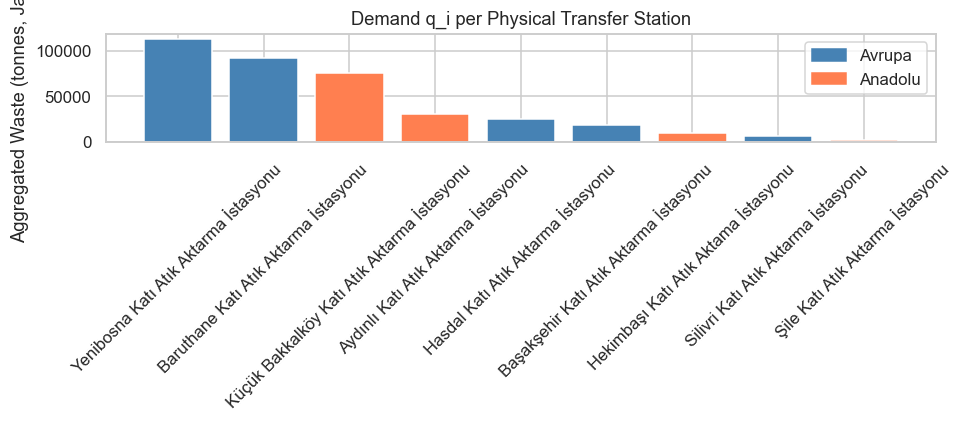

In [25]:
# Demand bar chart
fig, ax = plt.subplots(figsize=(9, 4))
sc = stations_clean.sort_values('total_waste_tonnes', ascending=False)
ax.bar(sc['name'], sc['total_waste_tonnes'], color=['steelblue' if s=='Avrupa' else 'coral' for s in sc['side']])
ax.set_ylabel('Aggregated Waste (tonnes, Jan 2025)')
ax.set_title('Demand q_i per Physical Transfer Station')
ax.tick_params(axis='x', rotation=45)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Avrupa'), Patch(color='coral', label='Anadolu')])
plt.tight_layout()
plt.savefig(OUT / 'station_demand.png', dpi=130)
plt.show()

---
## 7. Extract Disposal Facilities — Set **F**

In [26]:
# Disposal facility rules (from plan §3)
DISPOSAL_KEYWORDS = ['depolama', 'kompost', 'enerji', 'lfg', 'endüstriyel', 'endustriyel']
EXCLUDE_KEYWORDS  = ['aktarma', 'hizmet', 'elektronik', 'müdürlüğü', 'mudurlugu']

def is_disposal(name, status):
    n = str(name).lower()
    if any(k in n for k in EXCLUDE_KEYWORDS):
        return False
    if any(k in n for k in DISPOSAL_KEYWORDS):
        return True
    return False

disposal_mask = facilities_raw.apply(lambda r: is_disposal(r['facility_name'], r['status']), axis=1)
disposal_raw  = facilities_raw[disposal_mask & (facilities_raw['status'] == 'Mevcut')].copy()
disposal_raw['node_id'] = ['F' + str(i+1) for i in range(len(disposal_raw))]

print(f'Disposal/processing facilities (active, set F): {len(disposal_raw)}')
display(disposal_raw[['node_id','facility_name','node_type','located_region_name','lat','lon']])

Disposal/processing facilities (active, set F): 9


,node_id,facility_name,node_type,located_region_name,lat,lon
2,F1,Odayeri Düzenli Depolama Alanı Tıbbi Atık Yakm...,Disposal Site (F),Avrupa,41.216158,28.854565
5,F2,Kömürcüoda Düzenli Depolama Alanı,Disposal Site (F),Anadolu,41.150865,29.369271
8,F3,Odayeri Düzenli Depolama Alanı,Disposal Site (F),Avrupa,41.212720,28.857762
9,F4,Kömürcüoda Endüstriyel Atık Tesisi,Industrial,Anadolu,41.146185,29.376987
11,F5,Kömürcüoda Enerji Üretim (LFG) Tesisi,Energy/LFG (F),Anadolu,41.145754,29.377423
15,F6,Hasdal Enerji Üretim Tesisi,Energy/LFG (F),Avrupa,41.137224,28.930791
18,F7,Odayeri Enerji Üretim Tesisi,Energy/LFG (F),Avrupa,41.216189,28.853484
19,F8,Açık Kompost ve Geri Dönüşüm Tesisi,Composting (F),Anadolu,41.142845,29.370749
21,F9,Kompost Tesisi,Composting (F),Avrupa,41.221499,28.818358


In [27]:
# Map: S nodes + F nodes side by side
m_sf = folium.Map(location=[41.01, 28.95], zoom_start=9, tiles='CartoDB positron')

for _, row in stations_clean.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']], radius=10,
        color='blue', fill=True, fill_opacity=0.85,
        popup=folium.Popup(f"<b>{row['node_id']}: {row['name']}</b><br>Demand: {row['total_waste_tonnes']:,.0f} t", max_width=260)
    ).add_to(m_sf)

for _, row in disposal_raw.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']], radius=10,
        color='red', fill=True, fill_opacity=0.85,
        popup=folium.Popup(f"<b>{row['node_id']}: {row['facility_name']}</b><br>Type: {row['node_type']}", max_width=260)
    ).add_to(m_sf)

from folium.plugins import MiniMap
MiniMap().add_to(m_sf)
m_sf.save(OUT / 'S_and_F_nodes_map.html')
m_sf

---
## 8. Node Set Definition Summary

In [28]:
# Depot: IBB administrative HQ (objectid=1 in waste_facility.csv)
depot_row = facilities_raw[facilities_raw['objectid'] == 1].iloc[0]
depot = {
    'node_id': 'D0',
    'name': depot_row['facility_name'].strip(),
    'lat':  depot_row['lat'],
    'lon':  depot_row['lon'],
    'node_type': 'Depot',
}
print('Depot (node 0):')
print(json.dumps(depot, ensure_ascii=False, indent=2))

print(f'\nSet S  (transfer stations) : {len(stations_clean)} nodes')
print(f'Set F  (disposal facilities): {len(disposal_raw)} nodes')
print(f'Fleet  K (2025 total)       : {K_total} trucks (Asia {K_asia}, Europe {K_europe})')

Depot (node 0):
{
  "node_id": "D0",
  "name": "İBB Atık Yönetimi Müdürlüğü İBB Beyoğlu Ek Hizmet Binası",
  "lat": 41.0389079990667,
  "lon": 28.9715250005473,
  "node_type": "Depot"
}

Set S  (transfer stations) : 9 nodes
Set F  (disposal facilities): 9 nodes
Fleet  K (2025 total)       : 82 trucks (Asia 43, Europe 39)


---
## 9. Build Node Distance & Travel-Time Matrix

In [29]:
# Assemble full node table: Depot + S + F
depot_df = pd.DataFrame([{
    'node_id': 'D0', 'name': depot['name'],
    'lat': depot['lat'], 'lon': depot['lon'],
    'node_type': 'Depot',
    'demand_tonnes': 0, 'side': 'Avrupa'
}])

stations_nodes = stations_clean[['node_id','name','lat','lon','side']].copy()
stations_nodes['node_type'] = 'Transfer Station'
stations_nodes['demand_tonnes'] = stations_clean['total_waste_tonnes'].fillna(0)

disposal_nodes = disposal_raw[['node_id','facility_name','lat','lon','located_region_name']].copy()
disposal_nodes.columns = ['node_id','name','lat','lon','side']
disposal_nodes['node_type'] = 'Disposal'
disposal_nodes['demand_tonnes'] = 0

nodes = pd.concat([depot_df, stations_nodes, disposal_nodes], ignore_index=True)
nodes = nodes.dropna(subset=['lat','lon']).reset_index(drop=True)
print(f'Total nodes in network: {len(nodes)}')
display(nodes[['node_id','name','node_type','lat','lon','demand_tonnes']])

Total nodes in network: 19


,node_id,name,node_type,lat,lon,demand_tonnes
0,D0,İBB Atık Yönetimi Müdürlüğü İBB Beyoğlu Ek Hiz...,Depot,41.038908,28.971525,0.00
1,S1,Baruthane Katı Atık Aktarma İstasyonu,Transfer Station,41.048990,28.968704,92016.79
2,S2,Yenibosna Katı Atık Aktarma İstasyonu,Transfer Station,40.997941,28.825066,112835.76
3,S3,Başakşehir Katı Atık Aktarma İstasyonu,Transfer Station,41.146396,28.778397,18331.02
4,S4,Silivri Katı Atık Aktarma İstasyonu,Transfer Station,41.091038,28.290184,6838.18
5,S5,Hasdal Katı Atık Aktarma İstasyonu,Transfer Station,41.137224,28.930791,25427.36
6,S6,Küçük Bakkalköy Katı Atık Aktarma İstasyonu,Transfer Station,40.985205,29.129967,75807.66
7,S7,Hekimbaşı Katı Atık Aktama İstasyonu,Transfer Station,41.058319,29.113407,9169.97
8,S8,Aydınlı Katı Atık Aktarma İstasyonu,Transfer Station,40.860882,29.347151,30617.18
9,S9,Şile Katı Atık Aktarma İstasyonu,Transfer Station,41.153138,29.639464,1900.06


In [30]:
# Haversine distance matrix (km)
n = len(nodes)
lats = nodes['lat'].values
lons = nodes['lon'].values

dist_km = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            dist_km[i, j] = haversine(lats[i], lons[i], lats[j], lons[j])

dist_df = pd.DataFrame(dist_km, index=nodes['node_id'], columns=nodes['node_id'])
print('Distance matrix (km):')
display(dist_df.round(1))

Distance matrix (km):


node_id,D0,S1,S2,S3,S4,S5,S6,S7,S8,S9,F1,F2,F3,F4,F5,F6,F7,F8,F9
node_id,,,,,,,,,,,,,,,,,,,
D0,0.0,1.1,13.1,20.1,57.4,11.5,14.6,12.1,37.2,57.4,22.0,35.6,21.5,36.0,36.0,11.5,22.1,35.4,24.0
S1,1.1,0.0,13.3,19.3,57.1,10.3,15.3,12.2,38.0,57.4,20.9,35.4,20.4,35.9,35.9,10.3,20.9,35.3,22.9
S2,13.1,13.3,0.0,17.0,46.0,17.8,25.6,25.1,46.4,70.4,24.4,48.7,24.0,49.1,49.1,17.8,24.4,48.5,24.9
S3,20.1,19.3,17.0,0.0,41.4,12.8,34.5,29.7,57.3,72.1,10.0,49.5,9.9,50.1,50.2,12.8,10.0,49.6,9.0
S4,57.4,57.1,46.0,41.4,0.0,53.9,71.4,69.1,92.3,113.2,49.3,90.6,49.4,91.2,91.3,53.9,49.2,90.7,46.5
S5,11.5,10.3,17.8,12.8,53.9,0.0,23.8,17.6,46.5,59.4,10.9,36.7,10.4,37.4,37.4,0.0,10.9,36.8,13.3
S6,14.6,15.3,25.6,34.5,71.4,23.8,0.0,8.2,22.9,46.6,34.5,27.2,34.1,27.4,27.4,23.8,34.6,26.7,37.0
S7,12.1,12.2,25.1,29.7,69.1,17.6,8.2,0.0,29.4,45.3,27.9,23.8,27.4,24.1,24.2,17.6,28.0,23.5,30.7
S8,37.2,38.0,46.4,57.3,92.3,46.5,22.9,29.4,0.0,40.7,57.2,32.3,56.7,31.8,31.8,46.5,57.2,31.4,59.8


In [31]:
# Baseline travel-time matrix (minutes) at assumed free-flow speed v_free km/h
time_baseline_min = (dist_km / v_free) * 60
time_df = pd.DataFrame(time_baseline_min, index=nodes['node_id'], columns=nodes['node_id'])

print(f'Baseline travel-time matrix (minutes, assuming {v_free:.1f} km/h free-flow):')
display(time_df.round(1))

Baseline travel-time matrix (minutes, assuming 88.0 km/h free-flow):


node_id,D0,S1,S2,S3,S4,S5,S6,S7,S8,S9,F1,F2,F3,F4,F5,F6,F7,F8,F9
node_id,,,,,,,,,,,,,,,,,,,
D0,0.0,0.8,8.9,13.7,39.1,7.8,9.9,8.2,25.4,39.1,15.0,24.3,14.7,24.6,24.6,7.8,15.0,24.1,16.4
S1,0.8,0.0,9.1,13.1,38.9,7.0,10.4,8.3,25.9,39.1,14.3,24.2,13.9,24.5,24.5,7.0,14.3,24.0,15.6
S2,8.9,9.1,0.0,11.6,31.4,12.2,17.5,17.1,31.7,48.0,16.6,33.2,16.4,33.5,33.5,12.2,16.6,33.1,17.0
S3,13.7,13.1,11.6,0.0,28.2,8.7,23.5,20.3,39.1,49.2,6.8,33.7,6.8,34.2,34.2,8.7,6.8,33.8,6.1
S4,39.1,38.9,31.4,28.2,0.0,36.8,48.7,47.1,63.0,77.2,33.6,61.8,33.7,62.2,62.2,36.8,33.5,61.8,31.7
S5,7.8,7.0,12.2,8.7,36.8,0.0,16.2,12.0,31.7,40.5,7.4,25.1,7.1,25.5,25.5,0.0,7.4,25.1,9.1
S6,9.9,10.4,17.5,23.5,48.7,16.2,0.0,5.6,15.6,31.8,23.5,18.6,23.2,18.7,18.7,16.2,23.6,18.2,25.3
S7,8.2,8.3,17.1,20.3,47.1,12.0,5.6,0.0,20.1,30.9,19.0,16.2,18.7,16.5,16.5,12.0,19.1,16.0,20.9
S8,25.4,25.9,31.7,39.1,63.0,31.7,15.6,20.1,0.0,27.8,39.0,22.0,38.7,21.7,21.7,31.7,39.0,21.4,40.8


In [32]:
# Time-dependent travel-time tensor: time_r[h, i, j] = dist_km[i,j] / speed_r * 60
# speed_r for hour h = v_free / alpha_r[h]
hour_times = {}
for h in hours:
    speed_h = v_free / alpha_r[h]  # km/h for this hour
    hour_times[h] = (dist_km / max(speed_h, 1.0)) * 60

print('Time-dependent matrix computed for hours:', list(hour_times.keys()))
print(f'\nExample: D0 → S1 travel time by hour:')
d0_s1 = [(h, round(hour_times[h][0][1], 2)) for h in hours]
print(d0_s1)

Time-dependent matrix computed for hours: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

Example: D0 → S1 travel time by hour:
[(0, np.float64(1.17)), (1, np.float64(1.13)), (2, np.float64(1.09)), (3, np.float64(1.13)), (4, np.float64(1.15)), (5, np.float64(1.15)), (6, np.float64(1.21)), (7, np.float64(1.32)), (8, np.float64(1.4)), (9, np.float64(1.32)), (10, np.float64(1.35)), (11, np.float64(1.33)), (12, np.float64(1.4)), (13, np.float64(1.35)), (14, np.float64(1.4)), (15, np.float64(1.46)), (16, np.float64(1.43)), (17, np.float64(1.49)), (18, np.float64(1.56)), (19, np.float64(1.43)), (20, np.float64(1.3)), (21, np.float64(1.23)), (22, np.float64(1.21)), (23, np.float64(1.17))]


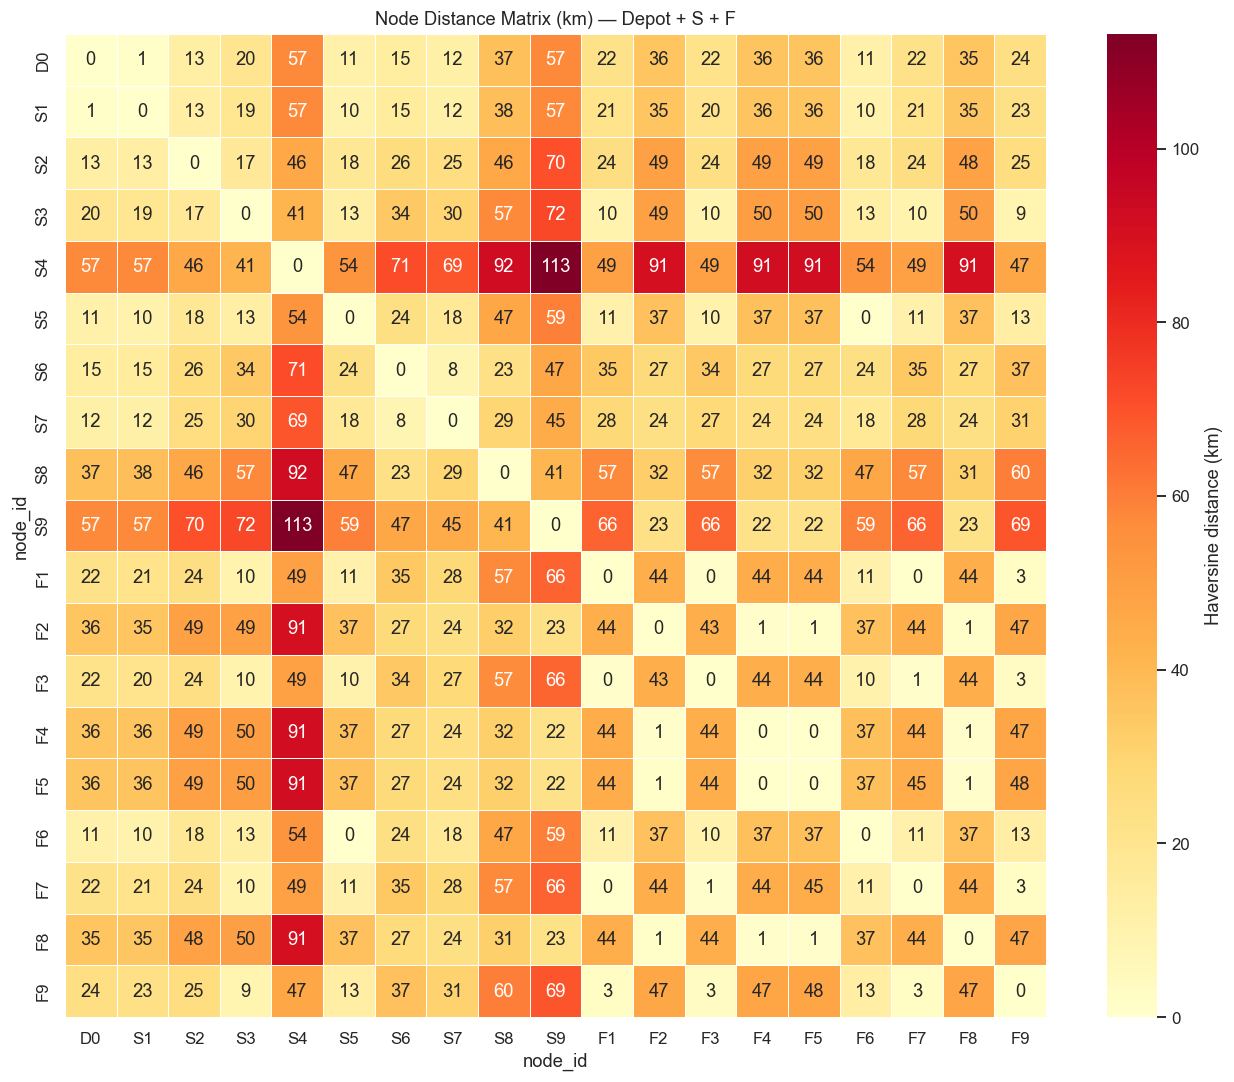

In [33]:
# Visualise distance matrix as heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(dist_df, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Haversine distance (km)'}, ax=ax)
ax.set_title('Node Distance Matrix (km) — Depot + S + F')
plt.tight_layout()
plt.savefig(OUT / 'distance_matrix_heatmap.png', dpi=130)
plt.show()

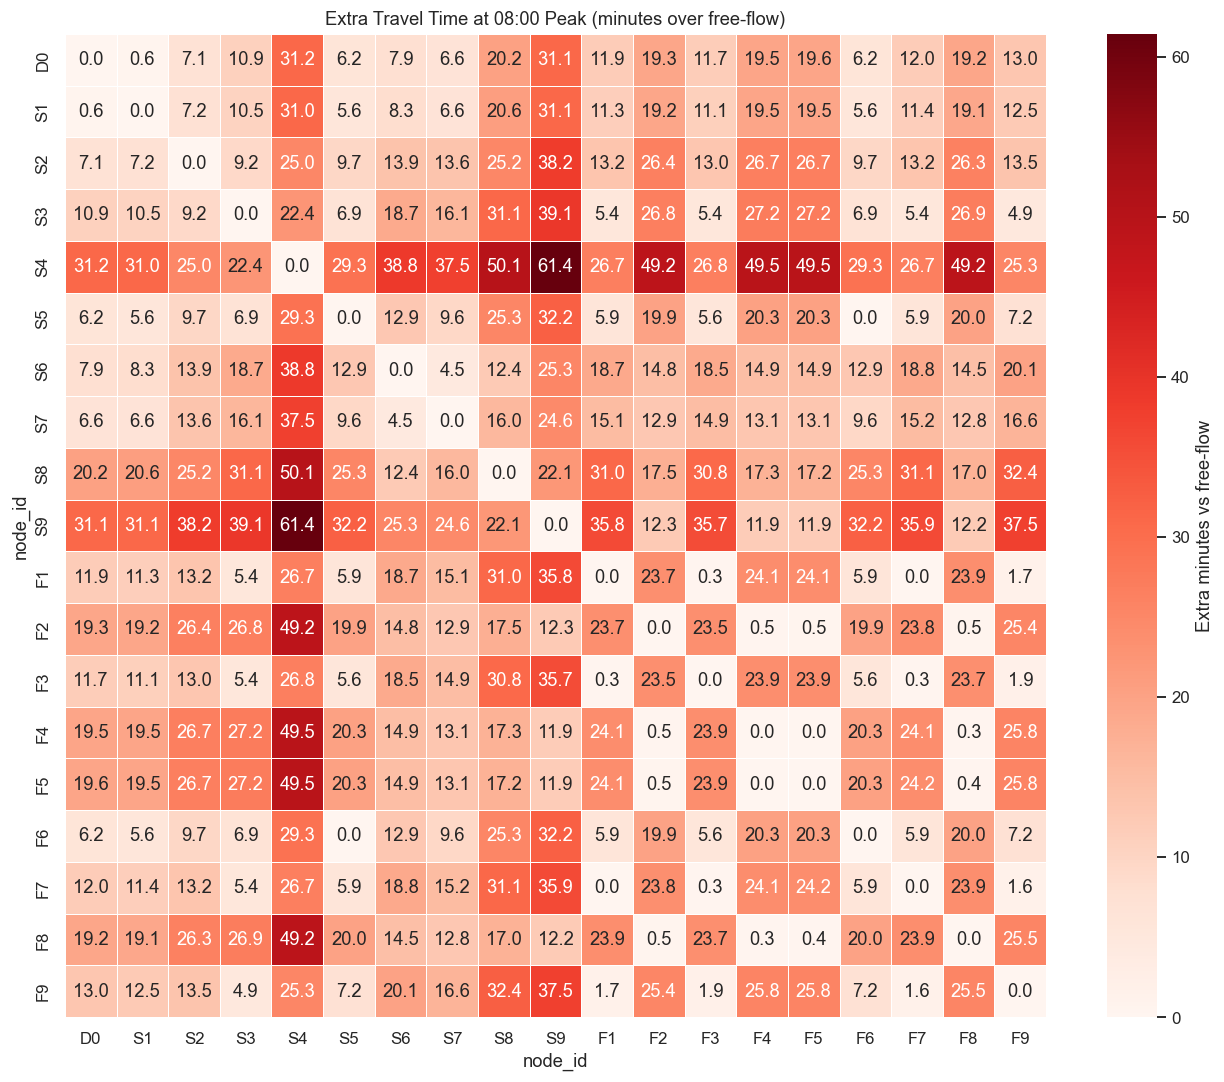

In [34]:
# Travel-time delta: peak hour (8) vs free-flow
delta_min = hour_times[8] - time_baseline_min
delta_df = pd.DataFrame(delta_min, index=nodes['node_id'], columns=nodes['node_id'])

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(delta_df, annot=True, fmt='.1f', cmap='Reds', linewidths=0.5,
            cbar_kws={'label': 'Extra minutes vs free-flow'}, ax=ax)
ax.set_title('Extra Travel Time at 08:00 Peak (minutes over free-flow)')
plt.tight_layout()
plt.savefig(OUT / 'peak_delta_heatmap.png', dpi=130)
plt.show()

---
## 10. Export Processed Data

In [35]:
# Save node table
nodes.to_csv(OUT / 'nodes.csv', index=False)

# Save distance and baseline time matrices
dist_df.to_csv(OUT / 'distance_matrix_km.csv')
time_df.to_csv(OUT / 'time_matrix_baseline_min.csv')

# Save alpha_r (JSON)
with open(OUT / 'alpha_r.json', 'w') as f:
    json.dump({'v_free_kmh': v_free, 'alpha_r': alpha_r}, f, indent=2)

# Save fleet reference
fleet_raw.to_csv(OUT / 'fleet.csv', index=False)

# CVRP instance summary
instance = {
    'depot': depot,
    'transfer_stations': stations_clean[['node_id','name','lat','lon','total_waste_tonnes','total_trips','side']].to_dict(orient='records'),
    'disposal_facilities': disposal_raw[['node_id','facility_name','lat','lon','located_region_name']].rename(columns={'facility_name':'name','located_region_name':'side'}).to_dict(orient='records'),
    'fleet_2025': {'asia': K_asia, 'europe': K_europe, 'total': K_total},
    'alpha_r': alpha_r,
    'v_free_kmh': v_free,
}
with open(OUT / 'cvrp_instance.json', 'w', encoding='utf-8') as f:
    json.dump(instance, f, ensure_ascii=False, indent=2)

print('Exports saved to ../outputs/:')
for p in sorted(OUT.iterdir()):
    print(f'  {p.name}')

Exports saved to ../outputs/:
  all_facilities_map.html
  alpha_r.json
  alpha_r_congestion.png
  cvrp_instance.json
  distance_matrix_heatmap.png
  distance_matrix_km.csv
  facility_types.png
  fleet.csv
  fleet_by_year.png
  hourly_speed_curve.png
  nodes.csv
  peak_delta_heatmap.png
  S_and_F_nodes_map.html
  speed_distributions.png
  speed_heatmap_hour_dow.png
  station_areas.png
  station_demand.png
  stations_map.html
  time_matrix_baseline_min.csv
  traffic_coverage_08h.html
  waste_distributions.png
  waste_volumes.png


---
## 11. EDA Findings Summary

| Topic | Finding |
|---|---|
| **Fleet (2025)** | 43 trucks (Anadolu) + 39 trucks (Avrupa) = **82 total** |
| **Transfer stations S** | **9 physical stations** with confirmed lat/lon; distinct from municipality sources |
| **Disposal facilities F** | Active disposal/processing nodes extracted from `waste_facility.csv` (Düzenli Depolama, Kompost, Enerji/LFG) |
| **Depot (node 0)** | IBB Atık Yönetimi Müdürlüğü (Beyoğlu) used as central depot |
| **Demand q_i** | Jan 2025 volumes aggregated from 48 municipalities to 9 stations via nearest-centroid assignment |
| **Traffic coverage** | 1.76M+ geohash-cell observations; full spatial coverage of Istanbul |
| **Congestion α_r** | Free-flow ~{v_free:.0f} km/h (01-05h 90th pct); peak hours 07-09 and 17-19 show highest α_r |
| **Data quality** | No missing values in any xlsx; traffic CSV has no nulls; WKT parses cleanly |
| **Watch: merge gap** | Municipality names ≠ station names — nearest-centroid assignment introduces ~±5 km error for boundary districts |
| **Watch: single month** | Only Jan 2025 traffic — may miss seasonal variation; acceptable for prototype |

**Next step:** Use `outputs/cvrp_instance.json` + `distance_matrix_km.csv` + `alpha_r.json` to formulate and solve the CVRP (MILP for small subset, GA/SA for full Istanbul).